# Customize OpenAI `GPT-OSS` models on Amazon SageMaker AI for improved accuracy

---

In this notebook, we explore how to use **gpt-oss-20b** or **gpt-oss-120b**, which is OpenAI’s smaller open-weight reasoning model from the gpt-oss series. You’ll learn how to fine-tune it on your dataset, evaluate its performance, and deploy it at scale with SageMaker.

**What is gpt-oss?**

OpenAI released **gpt-oss-20b** and **gpt-oss-120b** on **August 5, 2025**, as part of their first open-weight models since GPT-2. It is a **~21-billion-parameter and 120-billion-parameter mixture-of-experts (MoE) models**. It is released under the **Apache 2.0** license and designed for low-latency inference, efficient deployment on consumer hardware, strong reasoning, tool use, and instruction following.  

🔗 [openai/gpt-oss-120b on Hugging Face](https://huggingface.co/openai/gpt-oss-120b)

🔗 [openai/gpt-oss-20b on Hugging Face](https://huggingface.co/openai/gpt-oss-20b)

---

**Key Specifications**

| **Attribute** | **GPT-OSS-20B** | **GPT-OSS-120B** |
|:--------------|:----------------|:-----------------|
| **Total Parameters** | 20 billion | 120 billion |
| **Active Parameters per Token** | ~5.1 billion | ~5.1 billion |
| **Model Type / Architecture** | Transformer with Mixture-of-Experts (MoE): 64 experts total, 4 active per token | Transformer with Mixture-of-Experts (MoE): 128 experts total, 4 active per token |
| **Number of Layers** | 24 | 36 |
| **Context Length** | Up to **32,000 tokens** | Up to **128,000 tokens** |
| **Positional Embedding** | Rotary Positional Embedding (RoPE) | Rotary Positional Embedding (RoPE) |
| **Attention Patterns** | Alternating dense and locally banded sparse attention + grouped multi-query attention | Alternating dense and locally banded sparse attention + grouped multi-query attention |
| **Modalities** | Text-only | Text-only |
| **Training Data** | Diverse multilingual + code corpus | Expanded multilingual + high-quality reasoning and code corpus |
| **Inference Efficiency** | Optimized for single-GPU or lightweight deployment | Optimized for distributed multi-GPU clusters |
| **License** | Apache-2.0 | Apache-2.0 |
| **Intended Use** | Research, fine-tuning, and efficient inference | Advanced reasoning, long-context generation, and large-scale fine-tuning |


---

**Using This Notebook**

In this hands-on guide, you’ll explore the complete fine-tuning workflow with Amazon SageMaker:

1. **📂 Load a Sample Dataset**  
   Import a dataset from **Hugging Face** and prepare it for fine-tuning.

2. **⚙️ Fine-Tune Your Model**  
   Launch **SageMaker Training Jobs** to customize your model with your own data.

3. **📊 Evaluate Model Performance**  
   Run structured **Model Evaluation** to measure accuracy and performance.

4. **🚀 Deploy Seamlessly**  
   Deploy your fine-tuned model to **SageMaker Endpoints** for real-time inference.


In [ ]:
%pip install -Uq sagemaker datasets

In [ ]:
import boto3
import sagemaker
from sagemaker.local import LocalSession 
from PIL import Image
import torch

In [ ]:
region = boto3.Session().region_name

def create_sagemaker_session(region=None, local=False):
    if region is None:
        region = boto3.Session().region_name

    print(f"using region: {region}")
    # setup a local mode session for rapid prototyping
    sess_local = LocalSession() 
    sess_local.config = {"local": {"local_code": True}}
    print(f"setting up local mode session")
    # setup a remote session for remote job execution
    sess = sagemaker.Session(boto3.Session(region_name=region))
    print(f"setting up remote session")
    return sess, sess_local

sess, sess_local = create_sagemaker_session(region=region, local=False)


sagemaker_session_bucket = None
if sagemaker_session_bucket is None and sess is not None:
    # set to default bucket if a bucket name is not given
    sagemaker_session_bucket = sess.default_bucket()

role = sagemaker.get_execution_role()

In [ ]:
print(f"sagemaker role arn: {role}")
print(f"sagemaker bucket: {sess.default_bucket()}")
print(f"sagemaker session region: {sess.boto_region_name}")

## 01 - Download and Prepare Dataset for Fine-tuning `GPT-OSS`

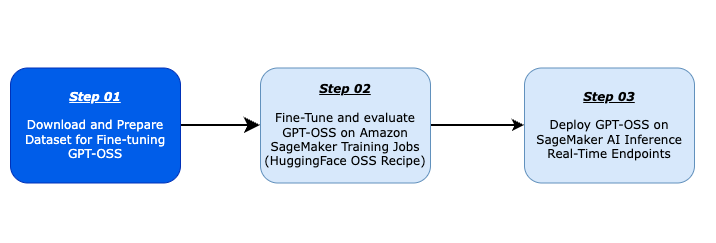

In [ ]:
import os
import re 
import json
import pprint
import numpy as np
from tqdm import tqdm
from typing import Any, Dict, List
from datasets import load_dataset

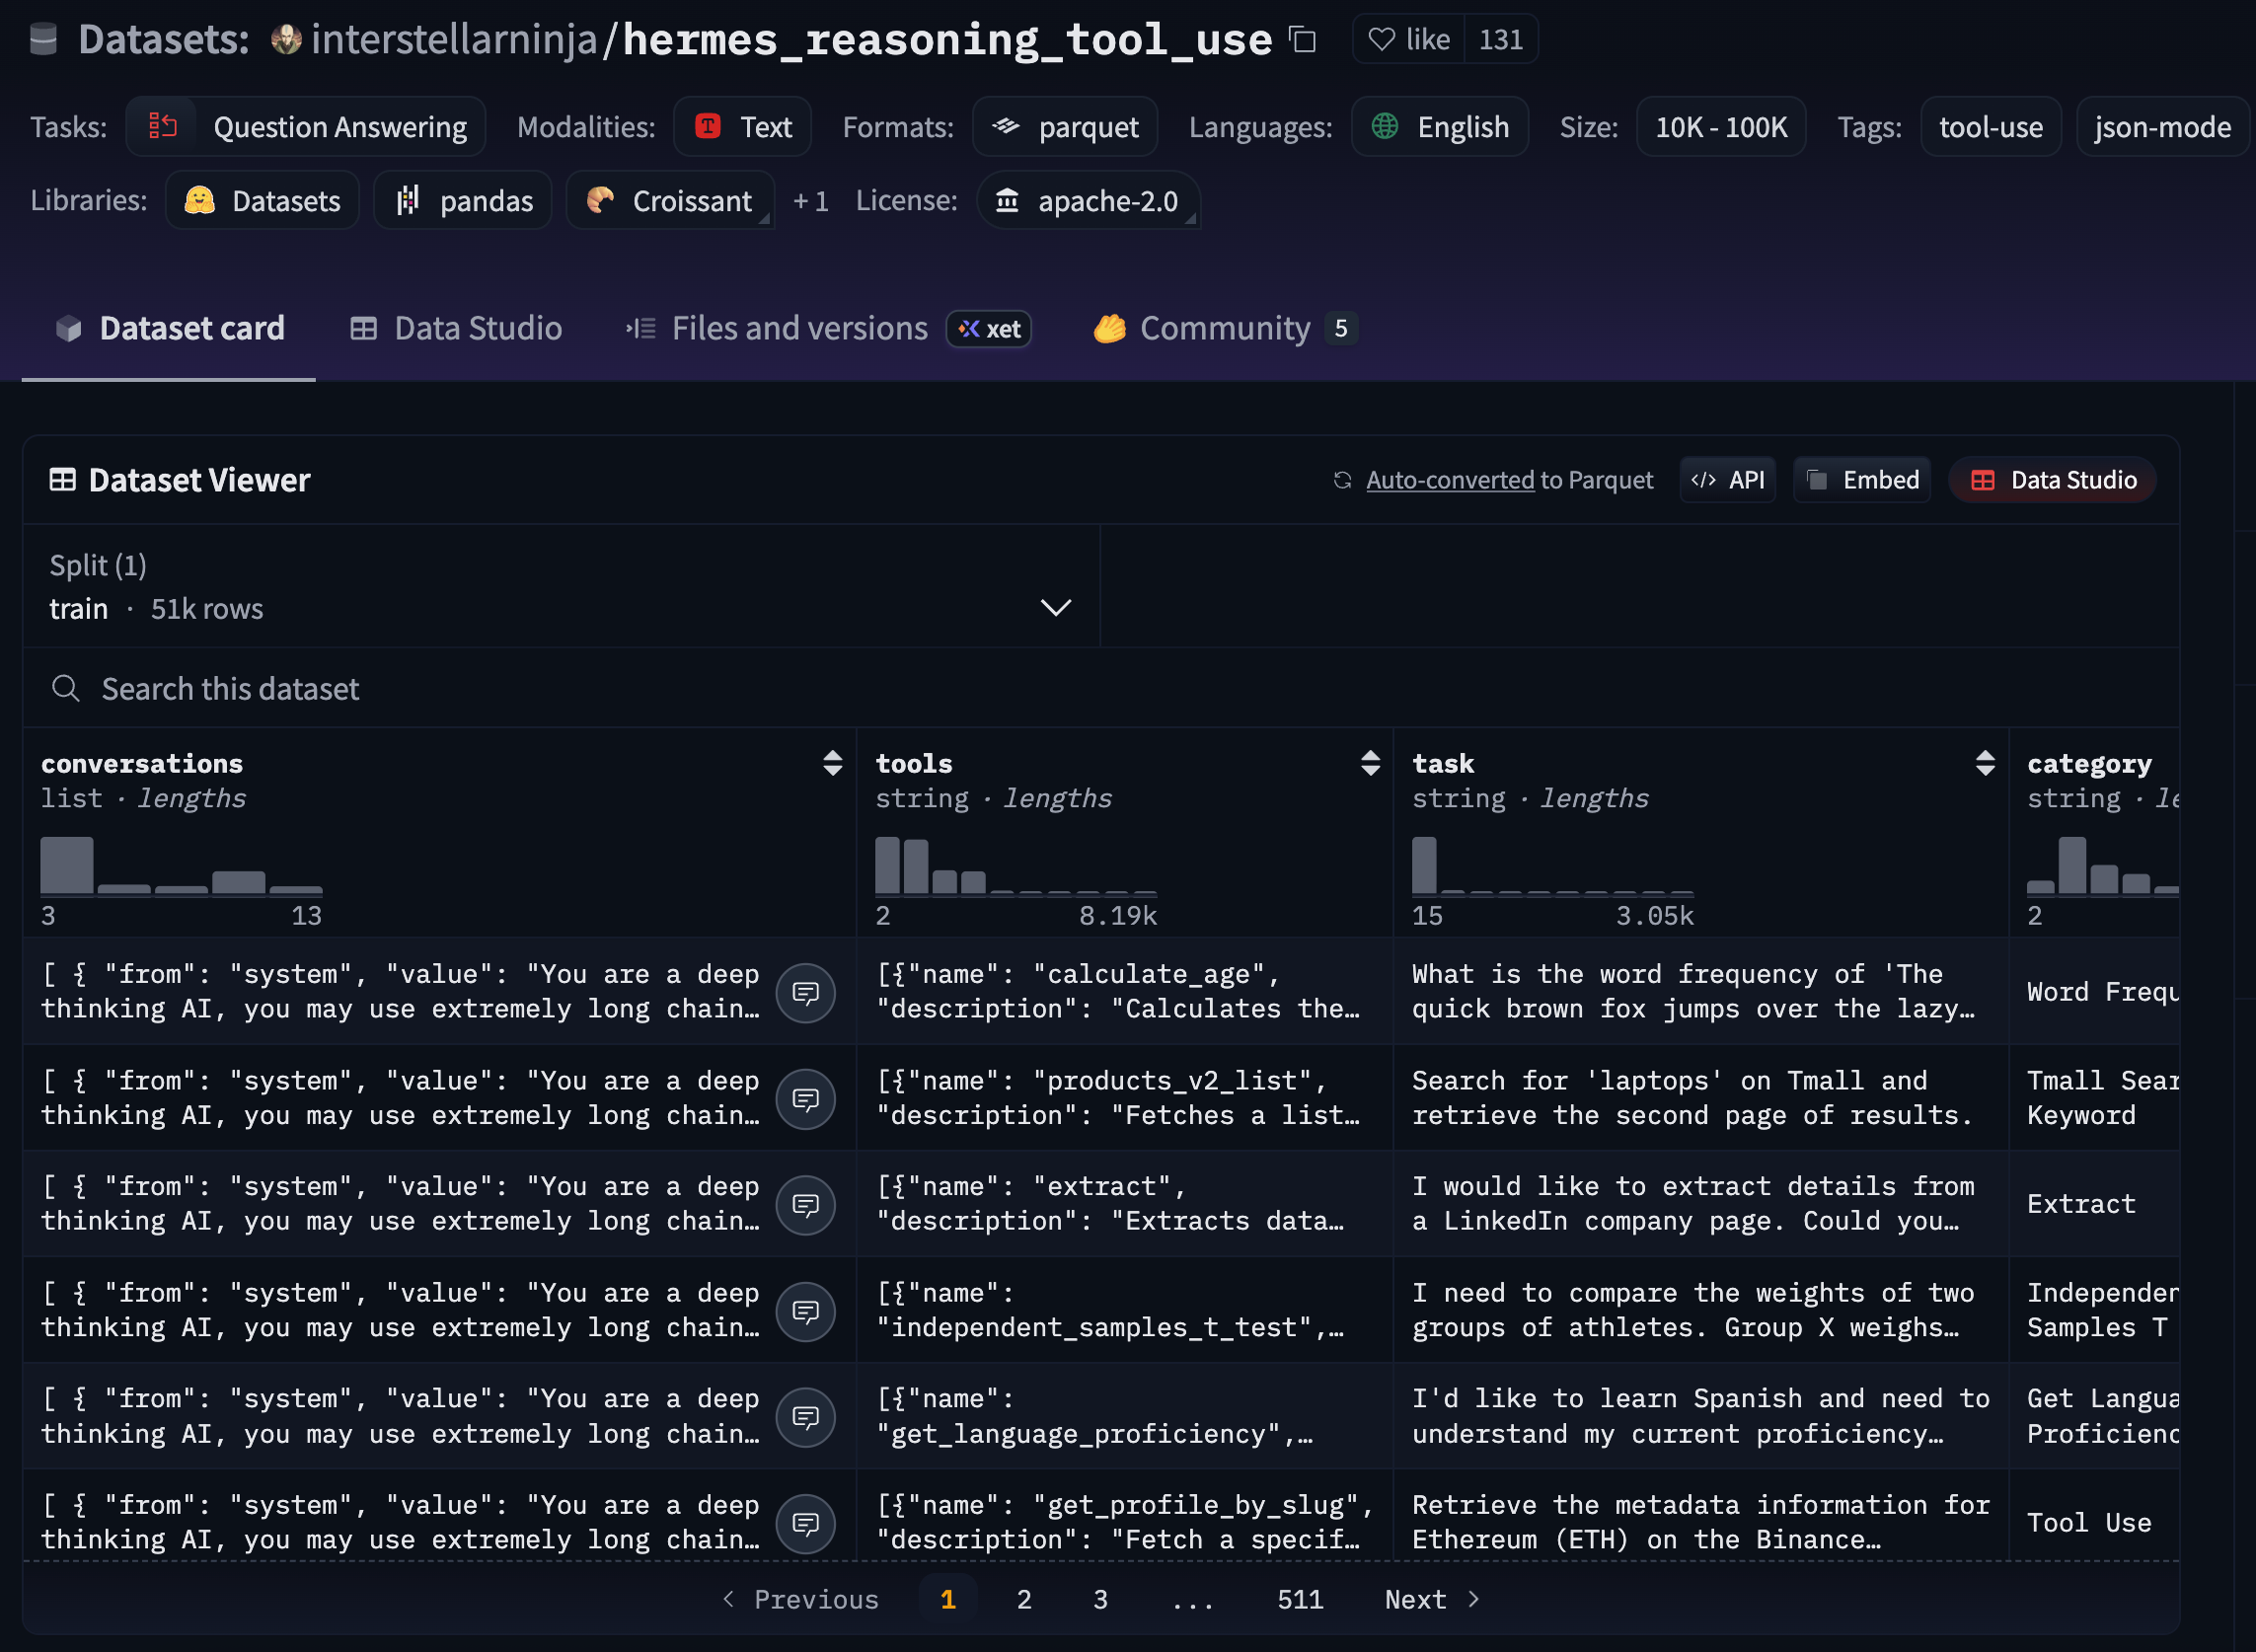

## 01.01 Download Dataset


#### [Hermes Reasoning Tool Use](https://huggingface.co/datasets/interstellarninja/hermes_reasoning_tool_use)

**Hermes Reasoning Tool Use** is a specialized dataset compiled by interstellarninja, containing approximately **50,000 entries** focused on reasoning and tool-use chains in AI assistants. The dataset is designed to support advanced function-calling, multi-step reasoning, and interactive workflows under instruct-style settings.

**Data Format & Structure**:

* Distributed in **JSON** format.
* Contains a single `train` split with ~50k records.
* Each record includes:

  * `tools_used` – a list of tool names invoked in the reasoning session
  * `user_instruction` – a natural-language prompt requiring tool usage or reasoning
  * `assistant_response` – the model’s answer which includes reasoning trace and tool calls
  * `tool_outputs` – the structured outputs returned from each tool invocation
  * `final_answer` – the concise result of the reasoning chain

**License**: Released under an **open-access research license** (please check the dataset card for the latest licensing terms on Hugging Face).

**Applications**:

The dataset can support a variety of advanced simulation and training tasks, including:

* Fine-tuning assistants to perform multi-step reasoning with external tool interfaces
* Agent-based workflows where models must call tools, interpret their outputs, and incorporate them into answers
* Benchmarking tool-use reasoning capabilities of LLMs
* Training models for interactive decision-making, function-calling, or knowledge-retrieval pipelines

If you like, I can pull more detailed metadata (field types, tool inventory, split sizes) from the dataset card and format for your notebook.


In [ ]:
dataset_parent_path = os.path.join(os.getcwd(), "tmp_cache_local_dataset")
os.makedirs(dataset_parent_path, exist_ok=True)


**Preparing Your Dataset in `messages`/`harmony` format**

This section walks you through creating a conversation-style dataset—the required `messages` format—for directly training LLMs using SageMaker AI.

**What Is the `messages` Format?**

The `messages` format structures instances as chat-like exchanges, wrapping each conversation turn into a role-labeled JSON array. It’s widely used by frameworks like TRL.

Example entry:

```json
{
  "messages": [
    { "role": "system", "content": "You are a helpful assistant.", "thinking": None},
    { "role": "user", "content": "How do I bake sourdough?", "thinking": None },
    { "role": "assistant", "content": "First, you need to create a starter by...", "thinking": "I am thinking..." }
  ]
}
```

In [ ]:
dataset_name = "interstellarninja/hermes_reasoning_tool_use"
dataset = load_dataset(dataset_name, split="train[:1000]")

In [ ]:
pprint.pp(dataset[0])

In [ ]:
print(f"total number of fine-tunable samples: {len(dataset)}")

##### This uses think tags and needs to change

In [ ]:
# Precompile regex patterns for efficiency and clarity
THINK_RE = re.compile(r"<think>(.*?)</think>", re.DOTALL)
TOOL_CALL_RE = re.compile(r"<tool_call>(.*?)</tool_call>", re.DOTALL)


def convert_to_messages_reasoning(row: Dict[str, Any]) -> Dict[str, List[Dict[str, Any]]]:
    """
    Convert a dataset row with 'conversations' into a messages dict.
    Behavior is preserved:
      - system/user content copied verbatim from indices 0 and 1.
      - assistant 'thinking' extracted from <think>...</think> (empty if absent).
      - assistant 'content' is all <tool_call> blocks re-wrapped and joined by '\n'.
    """
    conversations = row["conversations"]

    system_content = conversations[0]["value"]
    user_content = conversations[1]["value"]
    assistant_text = conversations[2]["value"]

    # Extract reasoning/thinking content
    think_match = THINK_RE.search(assistant_text)
    reasoning_content = think_match.group(1).strip() if think_match else ""

    # Extract and re-wrap all tool_call blocks, then join by newline
    tool_payloads = TOOL_CALL_RE.findall(assistant_text)
    assistant_content = "\n".join(f"<tool_call>{t}</tool_call>" for t in tool_payloads)

    return {
        "messages": [
            {"role": "system", "content": system_content, "thinking": None},
            {"role": "user", "content": user_content, "thinking": None},
            {"role": "assistant", "content": assistant_content, "thinking": reasoning_content},
        ]
    }


# Map over the dataset (behavior unchanged)
dataset = dataset.map(convert_to_messages_reasoning, remove_columns=dataset.column_names)

In [ ]:
dataset[0]

In [ ]:
dataset_filename = os.path.join(dataset_parent_path, f"{dataset_name.replace('/', '--').replace('.', '-')}.jsonl")
dataset.to_json(dataset_filename, lines=True)

## 01.02 Tokenize Dataset

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-20b")

In [ ]:
conversation = tokenizer.apply_chat_template(dataset[0]["messages"], tokenize=False)
print(conversation)

In [ ]:
def preprocess_function(example):
    return tokenizer.apply_chat_template(
        example['messages'], 
        return_dict=True, 
        padding="max_length", 
        max_length=4096, 
        truncation=True
    )


def label(x):
    x["labels"] = np.array(x["input_ids"])
    x["labels"][x["labels"]==tokenizer.pad_token_id] =- 100
    x["labels"] = x["labels"].tolist()
    return x


dataset = dataset.map(preprocess_function, remove_columns=dataset.column_names)
dataset = dataset.map(label)

#### Upload file to S3

Let's upload the data file to `S3` for SM TJ access during model training session.

In [ ]:
from datetime import datetime
from sagemaker.s3 import S3Uploader

Upload dataset in dictionary format.

In [ ]:
datetime_prefix = datetime.now().strftime('%Y%m%d%H%M%S')

In [ ]:
data_s3_uri = f"s3://{sess.default_bucket()}/aim3315-dataset/{datetime_prefix}"

uploaded_s3_uri_json = S3Uploader.upload(
    local_path=dataset_filename,
    desired_s3_uri=data_s3_uri
)
print(f"Uploaded {dataset_filename} to > {uploaded_s3_uri_json}")

Upload tokenized dataset in converted format

## 02 - Fine-Tune `GPT-OSS` on Amazon SageMaker AI using Training Jobs

In [ ]:
import time
import copy
from datetime import datetime
from jinja2 import Template
from sagemaker.pytorch import PyTorch
from getpass import getpass

In [ ]:
hf_token = getpass()

In [ ]:
job_name = 'openai--gpt-oss-20b'
run_name = f"spectrum-{dataset_name.replace('/', '--').replace('.', '-')}-{datetime.now().strftime("%Y%m%d%H%M%S")}"

In [ ]:
MLFLOW_TRACKING_SERVER_ARN = "arn:aws:sagemaker:us-east-1:015476483300:mlflow-tracking-server/sagemaker-tfc-ts"
reports_to = "mlflow"

training_env = {
    "MLFLOW_EXPERIMENT_NAME": f"{job_name}-v4",
    "MLFLOW_TAGS": '{"source.job": "smai-training-jobs", "source.type": "sft", "source.framework": "pytorch"}',
    "HF_TOKEN": hf_token,
    "MLFLOW_TRACKING_URI": MLFLOW_TRACKING_SERVER_ARN,
}

**Training Using `PyTorch` Estimator**
Leverages the official PyTorch SageMaker container to run a custom training script using the Accelerate and DeepSpeed libraries. This option is ideal for users who want full control over the training pipeline 

---
**Observability**: SageMaker AI has [SageMaker MLflow](https://docs.aws.amazon.com/sagemaker/latest/dg/mlflow.html) which enables you to accelerate generative AI by making it easier to track experiments and monitor performance of models and AI applications using a single tool.

You can choose to include MLflow as a part of your training workflow to track your model fine-tuning metrics in realtime by simply specifying a **mlflow** tracking arn.

Optionally you can also report to : **tensorboard**, **wandb**.

### 02: HuggingFace OSS Recipes`Spectrum` with SageMaker Training Jobs

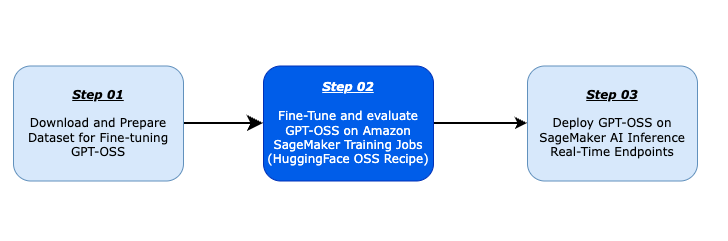

---
The YAML file (below) defines the core configuration for fine-tuning GPT‑OSS models on SageMaker. Below are the key sections and their purpose:

- **Model Setup**  
  - `model_name_or_path`: Specifies the pre-trained GPT‑OSS model to fine-tune (e.g., `openai/gpt-oss-20b`).
  - `attn_implementation`: Uses `kernels-community/vllm-flash-attn3` for faster attention via Flash Attention v3.
  - `torch_dtype`: Enables bfloat16 precision (`bf16`) to reduce memory usage without sacrificing accuracy.

- **Dataset**  
  - `dataset_id_or_path`: Path to the training dataset in `messages` format.
  - `max_seq_length`: Sets the token limit for each input sequence.
  - `packing`: Enables efficient token packing for better throughput during training.

- **Spectrum**  
  - Spectrum fine-tuning is a selective fine-tuning method for large language models that identifies the most informative layers based on their signal-to-noise ratio (SNR) and fine-tunes only those layers, freezing the rest; this approach improves training efficiency and model quality while reducing computational resource use compared to full fine-tuning

- **Training**  
  - `num_train_epochs`, `per_device_train_batch_size`, and `gradient_accumulation_steps`: Control training duration and batch sizing.
  - `gradient_checkpointing`: Reduces memory usage during training by trading off compute.
  - `optim`: Uses `adamw_torch_fused` for fused optimizer support.

- **Logging & Saving**  
  - Logs metrics to MLflow and saves checkpoints per epoch.
  - Seeds and reproducibility settings (`seed`, `save_strategy`) are pre-configured for consistent results.

This file is passed as input to the training script via Accelerate + DeepSpeed, allowing users to modify training behavior without changing code.

In [ ]:
yaml_template = """# Model arguments
model_name_or_path: openai/gpt-oss-20b
tokenizer_name_or_path: openai/gpt-oss-20b
model_revision: main
torch_dtype: bfloat16
attn_implementation: eager
use_liger: false
bf16: true
tf32: true
output_dir: /opt/ml/output/openai/gpt-oss-20b/spectrum/

# Dataset arguments
dataset_id_or_path: /opt/ml/input/data/training/interstellarninja--hermes_reasoning_tool_use.jsonl
max_seq_length: 4096
packing: false

# Spectrum Config
mxfp4: true
spectrum_config_path: configs/spectrum/openai/snr_results_openai-gpt-oss-20b_unfrozenparameters_30percent.yaml

# Modality type
modality_type: "text"

# Training arguments
num_train_epochs: 1
per_device_train_batch_size: 4
gradient_accumulation_steps: 2
gradient_checkpointing: true
gradient_checkpointing_kwargs:
  use_reentrant: true
learning_rate: 1.0e-4 
lr_scheduler_type: cosine
warmup_ratio: 0.1

# Logging arguments
logging_strategy: steps
logging_steps: 2
report_to:
- {{ reports_to }}
run_name: {{ run_name }}
save_strategy: "epoch"
seed: 42

"""

config_filename = "gpt-oss-20b--vanilla-spectrum.yaml"

In [ ]:
# Render template and plug dynamic values
rendered_yaml = Template(yaml_template).render(
    reports_to=reports_to,
    run_name=run_name
)

# Save to file (optional)
with open(os.path.join(
    "./sagemaker_code/hf_recipes/openai", 
    config_filename
), "w") as f:
    f.write(rendered_yaml)

In [ ]:
pytorch_estimator = PyTorch(
    image_uri=f"763104351884.dkr.ecr.{region}.amazonaws.com/pytorch-training:2.7.1-gpu-py312-cu128-ubuntu22.04-sagemaker",
    entry_point="sm_accelerate_train.sh",
    source_dir="sagemaker_code",
    instance_type="ml.p4de.24xlarge",
    instance_count=1,
    base_job_name=f"oss-recipe-{job_name}",
    role=role,
    volume_size=1024,
    py_version="py312",
    keep_alive_period_in_seconds=3600,
    environment=training_env,
    sagemaker_session=sess,
    hyperparameters={
        "config": "hf_recipes/openai/gpt-oss-20b--vanilla-spectrum.yaml"
    }
)

In [ ]:
# fit or train
pytorch_estimator.fit(
    {
        "training": uploaded_s3_uri_json
    }, 
    wait=True
)

In [ ]:
from sagemaker.estimator import Estimator

pytorch_estimator = Estimator.attach(
    training_job_name="oss-recipe-openai--gpt-oss-20b-2025-11-02-18-31-09-674"
)

s3_model_data_uri = pytorch_estimator.model_data
print(f"Fine-tuned model location: {s3_model_data_uri}")

## 03 - Deploy GPT-OSS on SageMaker AI Inference Real-Time Endpoints

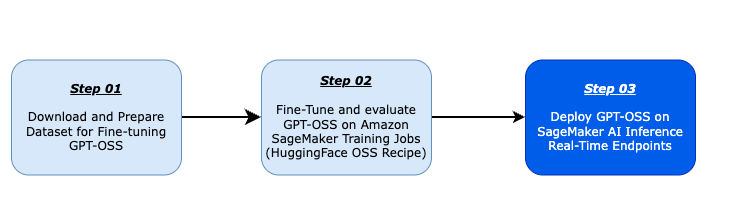

Once you have your fine-tuned LLM weights packaged as a `model.tar.gz` in Amazon S3, you can deploy them to a real-time Amazon SageMaker endpoint for low-latency inference. SageMaker handles the provisioning of GPU-backed infrastructure, model loading, and scaling, so you can focus on serving predictions without managing servers. By selecting an appropriate inference container (such as DJL with vLLM or Hugging Face TGI), configuring environment variables for model parameters (e.g., tensor parallelism, max sequence length, precision), and choosing the right instance type, you can quickly expose your model via a secure, fully managed API endpoint that supports both synchronous and streaming text generation. The structure for a custom LLM deployment is as below, in essence we need to add our custom inference logic `model.py`, `serving.properties` and `requirements.txt` in the same path as the model weights and prep the model for deployment.

**SageMaker LMI - vLLM Framework (Recommended)**
Leverages vLLM (Very Large Language Model), a high-performance inference engine specifically optimized for large language models. This approach delivers:

**Performance Advantages:**
- **Higher Throughput**: Up to 24x higher serving throughput compared to standard Transformers
- **Lower Latency**: Optimized CUDA kernels and memory management reduce response times
- **Better GPU Utilization**: Advanced memory pooling and batching strategies maximize hardware efficiency
- **Continuous Batching**: Dynamic batching of requests improves overall system throughput

**Technical Optimizations:**
- **PagedAttention**: Revolutionary attention algorithm that reduces memory fragmentation and enables larger batch sizes
- **Optimized CUDA Kernels**: Custom kernels for attention, activation functions, and layer normalization
- **Memory Efficiency**: Smart memory management reduces GPU memory usage by up to 50%
- **Tensor Parallelism**: Built-in support for multi-GPU inference with automatic model sharding

**Production Benefits:**
- **Cost Efficiency**: Higher throughput per GPU reduces infrastructure costs
- **Scalability**: Better handling of concurrent requests and traffic spikes
- **Quantization Support**: Built-in support for FP16, INT8, and other quantization methods
- **Streaming Support**: Native support for streaming responses with minimal latency overhead

**Why vLLM is Preferred:**
vLLM is specifically designed for production deployment of large language models like GPT-OSS. While Transformers provides excellent compatibility and ease of use, vLLM's specialized optimizations make it the superior choice for:
- Production environments requiring high throughput
- Cost-sensitive deployments where GPU efficiency matters
- Applications needing low-latency responses
- Scenarios with variable or high concurrent request loads

For development and testing, either option works well. For production deployments, vLLM's performance advantages typically result in 2-5x better cost-performance ratios compared to standard Transformers deployment.

---

In [ ]:
import os
import boto3
import json
import sagemaker
import tarfile
from datetime import datetime
from sagemaker.s3 import S3Downloader, S3Uploader
from sagemaker.compute_resource_requirements.resource_requirements import ResourceRequirements

### Prepare for Deployment

In [ ]:
local_model_path = "./tmp_cache_local_model"
os.makedirs(local_model_path, exist_ok=True)

In [ ]:
local_model_path

In [ ]:
S3Downloader.download(
    s3_uri=s3_model_data_uri,
    local_path=local_model_path
)
print(f"download model file to {local_model_path}")

In [ ]:
local_gpt_oss_model_path = os.path.join(local_model_path, "gpt-oss-model-finetuned-spectrum")
os.makedirs(local_gpt_oss_model_path, exist_ok=True)


def untar_file(tar_path: str, destination: str) -> None:

    if not os.path.isfile(tar_path):
        raise FileNotFoundError(f"The file '{tar_path}' does not exist.")

    os.makedirs(destination, exist_ok=True)

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=destination)
        print(f"Extracted '{tar_path}' to '{destination}'.")


# untar model file
untar_file(
    tar_path=os.path.join(local_model_path, os.path.basename(s3_model_data_uri)), 
    destination=local_gpt_oss_model_path
)

In [ ]:
model_s3_uri = f"s3://{sess.default_bucket()}/{datetime.now().strftime('%y%m%d%H%M%S%f')}"

uploaded_model_s3_uri = S3Uploader.upload(
    local_path=local_gpt_oss_model_path,
    desired_s3_uri=model_s3_uri
)
print(f"Uploaded {local_gpt_oss_model_path} to > {uploaded_model_s3_uri}")

### Deploy as a SageMaker Endpoint

In [ ]:
uploaded_model_s3_uri

In [ ]:
region = boto3.Session().region_name

inference_image = f"763104351884.dkr.ecr.{region}.amazonaws.com/djl-inference:0.34.0-lmi16.0.0-cu128"

model_name = sagemaker.utils.name_from_base(f"sft-tuned-gpt-oss-20b")
inference_component_name = f"ic-{model_name}"
endpoint_name = model_name

instance_type = "ml.g5.48xlarge"
num_gpu = 4

In [ ]:
print(f"Your IC name >> {inference_component_name} and Endpoint name >> {endpoint_name}")

In [ ]:
model = sagemaker.Model(
    image_uri=inference_image,
    role=role,
    env={
        "HF_MODEL_ID": f"{uploaded_model_s3_uri}/openai/gpt-oss-20b",
        "OPTION_TRUST_REMOTE_CODE": "true",
        "SERVING_FAIL_FAST": "true",
        "OPTION_ASYNC_MODE": "true",
        "OPTION_ROLLING_BATCH": "disable",
        "OPTION_TENSOR_PARALLEL_DEGREE": json.dumps(num_gpu),
        "OPTION_ENTRYPOINT": "djl_python.lmi_vllm.vllm_async_service",
        "OPTION_MAX_MODEL_LEN": "4096"
    },
)

In [ ]:
model.deploy(
    initial_instance_count=1,
    instance_type=instance_type,
    inference_component_name=inference_component_name,
    container_startup_health_check_timeout=900,
    resources=ResourceRequirements(requests={"num_accelerators": num_gpu, "copies": 1, "memory": 1024*10,}),
    endpoint_name=endpoint_name,
    endpoint_type=sagemaker.enums.EndpointType.INFERENCE_COMPONENT_BASED,
)

## 04 - Sample Inference

---

Now with the endpoint name handy, we're ready to invoke the tuned GPT-OSS model using `sagemaker.Predictor`.

In [ ]:
import boto3
from sagemaker import serializers, deserializers

In [ ]:
region = boto3.Session().region_name

endpoint_name = "<>"  #Mention your endpoint name here

In [ ]:
dataset_name = "interstellarninja/hermes_reasoning_tool_use"
dataset_test = load_dataset(dataset_name, split="train[1000:1010]")
dataset_test = dataset_test.map(
    convert_to_messages_reasoning, 
    remove_columns=dataset_test.column_names
)
sample = dataset_test[2]['messages'][:-1]

In [ ]:
llm = sagemaker.Predictor(
    endpoint_name=endpoint_name,
    sagemaker_session=sess,
    serializer=sagemaker.serializers.JSONSerializer(),
    deserializer=sagemaker.deserializers.JSONDeserializer(),
    component_name=inference_component_name
)

In [ ]:
payload = {
    "messages": sample,
    "max_tokens": 4096
}
res = llm.predict(payload)

In [ ]:
print(f"-* SAMPLE *-")

print(sample)
print(f"-* MODEL REASONING *-")
print("-----\n" + res["choices"][0]["message"]["reasoning_content"] + "\n-----\n")
print(f"-* MODEL RESPONSE *-")
print("-----\n" + res["choices"][0]["message"]["content"] + "\n-----\n")
print(res["usage"])